In [1]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import plotly.graph_objects as go
%matplotlib inline

In [2]:
def fetch_binance_data(symbol='BTC/USDT', timeframe='1m', limit=1000):
    exchange = ccxt.binance()
    data = exchange.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit, params = {"paginate": True})
    df = pd.DataFrame(data, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df

In [3]:
df = fetch_binance_data(symbol='BTC/USDT', timeframe='1m', limit=1000)

In [35]:
df.head()

,open,high,low,close,volume
timestamp,,,,,
2025-04-29 13:13:00,94817.80,94835.00,94795.48,94831.99,8.67968
2025-04-29 13:14:00,94832.00,94835.00,94782.61,94782.61,4.45582
2025-04-29 13:15:00,94782.60,94782.61,94661.00,94664.55,21.38227
2025-04-29 13:16:00,94664.55,94666.67,94611.41,94652.18,28.85771
2025-04-29 13:17:00,94652.17,94665.72,94629.27,94659.80,13.31618


In [5]:
def plot_price_data(df):
    fig = go.Figure()

    # === Price Line ===
    fig.add_trace(go.Scatter(
        x=df.index, y=df['close'],
        mode='lines', name='Price', line=dict(color='black')
    ))

    fig.show()

In [6]:
plot_price_data(df)

# Tick Imbalance Bars

In [19]:
#bar_data = [] 
#bar_data.append(df.iloc[0])
#print(bar_data)

#bar_df = pd.DataFrame(bar_data)

#bar_df

In [29]:
def build_tick_imbalance_bars(df, imbalance_threshold=10):
    bars = []
    theta_t = 0
    bar_data = []

    b_t_prev = 1
    new_bar = False

    df = df.sort_index().copy()
    df = df[['open', 'high', 'low', 'close', 'volume']].dropna()

    for i in range(1, len(df)):
        #prev_close = df['close'].iloc[i-1]
        #curr_close = df['close'].iloc[i]

        #b_t = 1 if curr_close > prev_close else -1
        
        delta = df['close'].iloc[i] - df['close'].iloc[i-1]

        #if delta == 0:
        #    b_t = b_t_prev
        #else: 
        #    b_t = int(np.sign(delta))
    
        # this enforces the b_0 = b_T boundary condition for new bars
        if new_bar:
            b_t = b_t_prev
            new_bar = False
        else: 
            if delta == 0:
                b_t = b_t_prev
            else:
                b_t = int(np.sign(delta))


        b_t_prev = b_t
        theta_t += b_t
        bar_data.append(df.iloc[i])

        if abs(theta_t) >= imbalance_threshold:
            bar_df = pd.DataFrame(bar_data)
            o = bar_df['open'].iloc[0]
            h = bar_df['high'].max()
            l = bar_df['low'].min()
            c = bar_df['close'].iloc[-1]
            v = bar_df['volume'].sum()
            t = bar_df.index[-1]

            bars.append({'time':t, 'open':o, 'high':h, 'low':l, 'close': c, 'volume':v})

            new_bar = True
            theta_t = 0
            bar_data = []

    #bars_df = bars_df.reset_index()
    #bars_df = pd.DataFrame(bars).set_index('time')
    bars_df = pd.DataFrame(bars)
    return bars_df


In [30]:
tib_df = build_tick_imbalance_bars(df, 3)
tib_df.head()


,time,open,high,low,close,volume
0,2025-04-29 13:16:00,94832.00,94835.00,94611.41,94652.18,54.69580
1,2025-04-29 13:23:00,94652.17,94825.01,94590.48,94825.00,91.26511
2,2025-04-29 13:28:00,94825.01,94891.04,94784.70,94869.99,60.45366
3,2025-04-29 13:31:00,94869.99,94948.41,94794.50,94948.40,42.95263
4,2025-04-29 13:38:00,94948.41,95033.70,94703.20,94703.20,160.16405


In [31]:
print(f"Bars formed: {len(tib_df)}")

Bars formed: 103


In [11]:
def plot_candles(bars_df, title="Tick Imbalance Bars"):
    
    fig, ax = plt.subplots(figsize=(14, 6))
    width = 0.6

    for i in range(len(bars_df)):
        
        o, h, l, c = bars_df.iloc[i][['open', 'high', 'low', 'close']]
        color = 'green' if c >= o else 'red'
        ax.plot([i, i], [l, h], color='black')
        ax.add_patch(plt.Rectangle((i - width/2, min(o, c)), width, abs(c - o), color=color))
        
    ax.set_title(title)
    ax.set_xlabel('Bar Index')
    ax.set_ylabel('Price')
    #ax.set_xlim(-1, len(bar_df))
    ax.grid(True)
        
    plt.show()

In [23]:
tib_df.head()

,time,open,high,low,close,volume
0,2025-04-29 13:16:00,94832.00,94835.00,94611.41,94652.18,54.69580
1,2025-04-29 13:21:00,94652.17,94722.26,94590.48,94715.18,62.88905
2,2025-04-29 13:24:00,94715.18,94850.00,94715.17,94840.00,40.04343
3,2025-04-29 13:31:00,94840.00,94948.41,94790.09,94948.40,91.73892
4,2025-04-29 13:38:00,94948.41,95033.70,94703.20,94703.20,160.16405


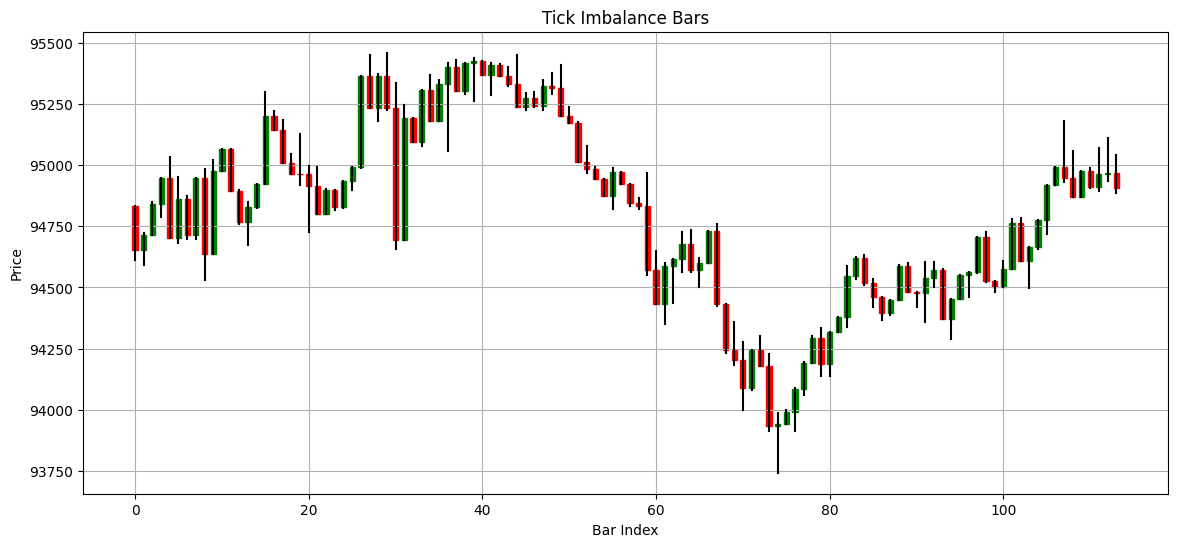

In [24]:
plot_candles(tib_df)

In [25]:
def plot_candles_with_volume(bars_df, title="Tick Imbalance Bars"):
    import matplotlib.pyplot as plt

    bars_df = bars_df.reset_index(drop=True)
    fig, (ax_price, ax_vol) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                           gridspec_kw={'height_ratios': [3, 1]})

    width = 0.6

    for i in range(len(bars_df)):
        o, h, l, c = bars_df.iloc[i][['open', 'high', 'low', 'close']]
        v = bars_df.iloc[i]['volume']
        color = 'green' if c >= o else 'red'

        # Candle (Price)
        ax_price.plot([i, i], [l, h], color='black', linewidth=1)
        ax_price.add_patch(plt.Rectangle((i - width/2, min(o, c)),
                                         width,
                                         abs(c - o),
                                         color=color))

        # Volume bar
        ax_vol.bar(i, v, width=width, color=color)

    ax_price.set_title(title)
    ax_price.set_ylabel("Price")
    ax_vol.set_ylabel("Volume")
    ax_vol.set_xlabel("Bar Index (event-based)")
    ax_price.grid(True)
    ax_vol.grid(True)

    plt.tight_layout()
    plt.show()

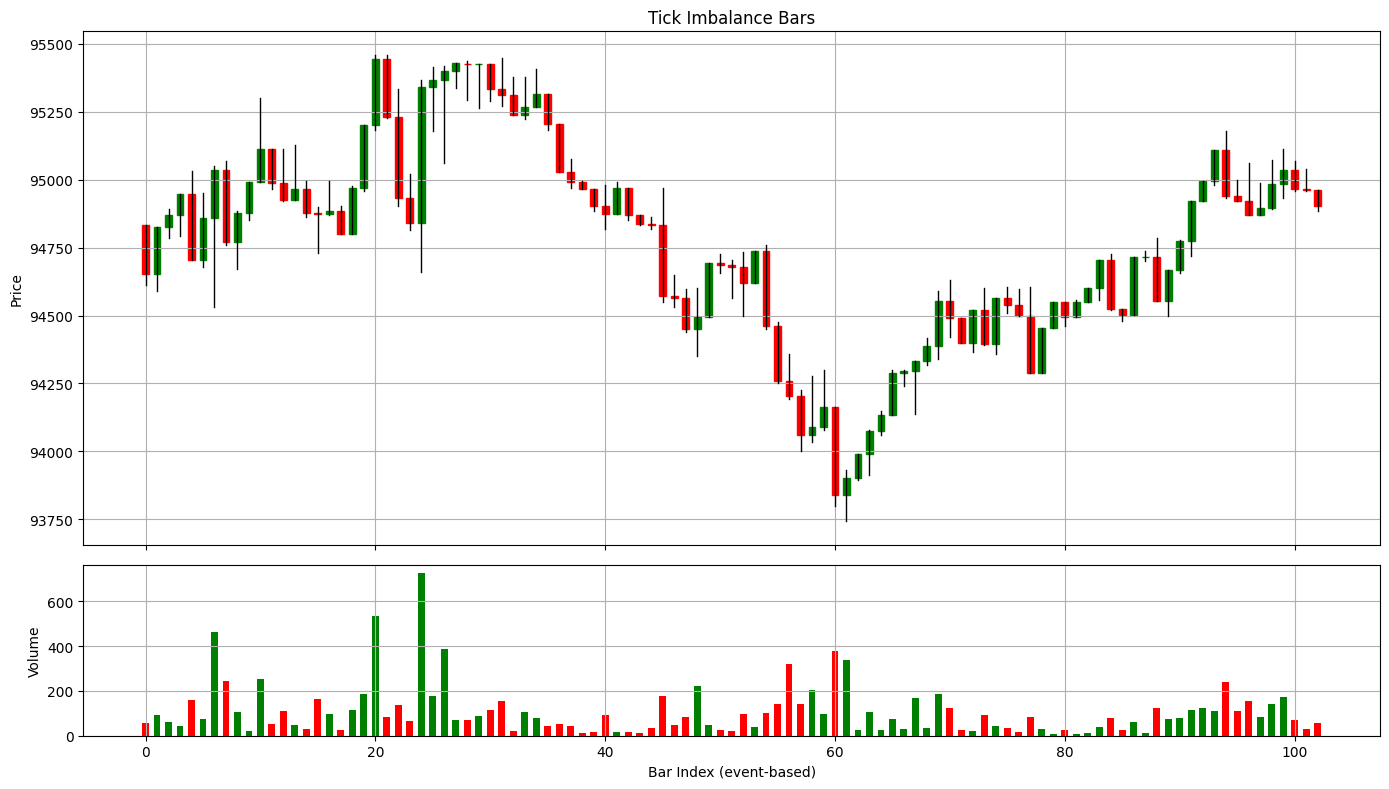

In [32]:
plot_candles_with_volume(tib_df)

In [16]:
def plot_candles_with_volume_time(bars_df, title="Tick Imbalance Bars (Time X-Axis)"):
    import matplotlib.pyplot as plt
    import pandas as pd
    import matplotlib.dates as mdates

    # Ensure 'time' is a datetime index
    if 'time' in bars_df.columns:
        bars_df = bars_df.set_index('time')

    fig, (ax_price, ax_vol) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                           gridspec_kw={'height_ratios': [3, 1]})

    width = pd.Timedelta(minutes=2)  # candle width — adjust to suit your bar frequency
    #width = width = pd.Timedelta(...) 

    for time, row in bars_df.iterrows():
        o, h, l, c = row[['open', 'high', 'low', 'close']]
        v = row['volume']
        color = 'green' if c >= o else 'red'

        # Candle wick
        ax_price.plot([time, time], [l, h], color='black', linewidth=1)

        # Candle body
        ax_price.add_patch(plt.Rectangle((time - width / 2, min(o, c)),
                                         width,
                                         abs(c - o),
                                         color=color))

        # Volume bar
        ax_vol.bar(time, v, width=width, color=color)

    # Format x-axis as datetime
    ax_price.set_title(title)
    ax_price.set_ylabel("Price")
    ax_vol.set_ylabel("Volume")
    ax_vol.set_xlabel("Time")

    ax_price.grid(True)
    ax_vol.grid(True)

    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

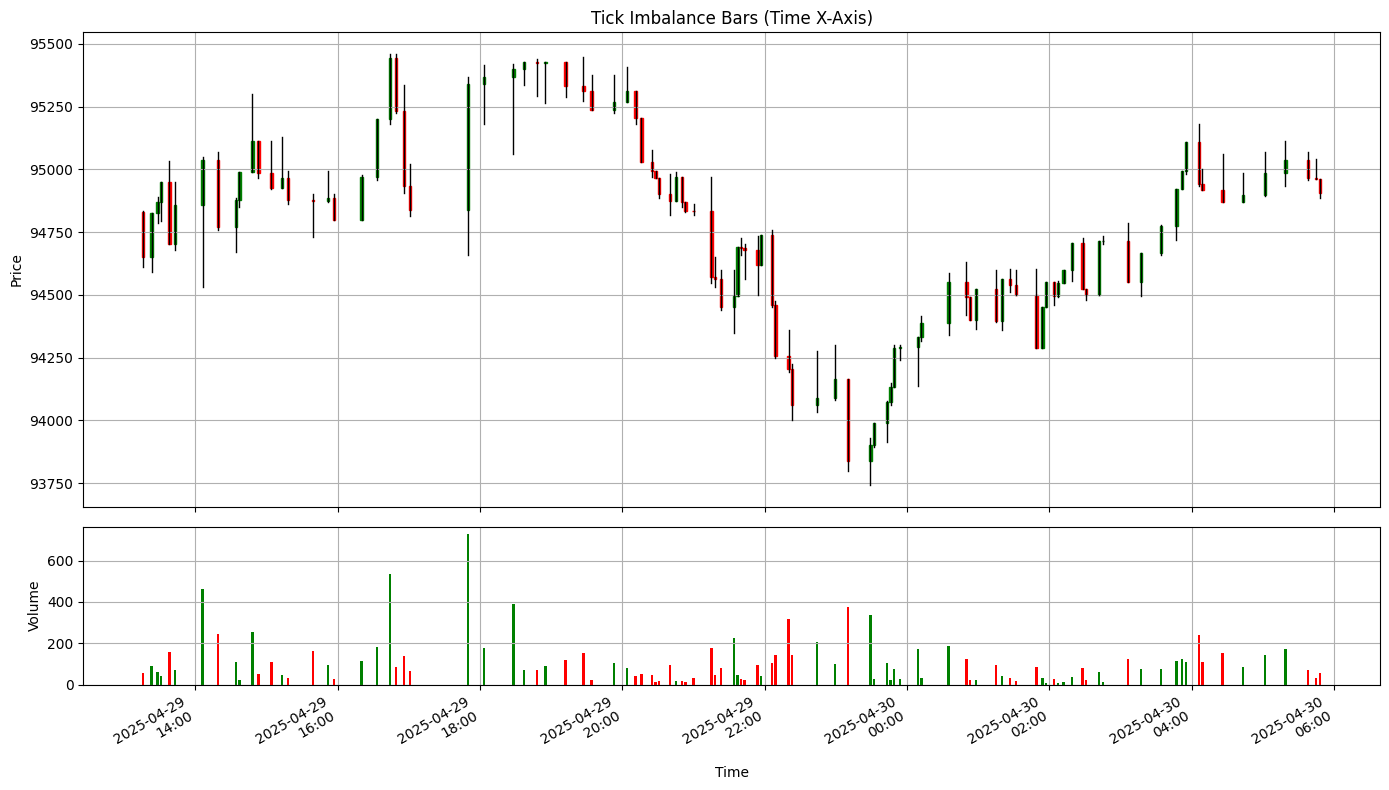

In [34]:
#tib_df_3 = build_tick_imbalance_bars(df, 3)
plot_candles_with_volume_time(tib_df)

In [28]:
plot_price_data(df)